## 1.读取数据

In [8]:
import pandas as pd
import pyarrow

print("开始读取数据：")
add_to_cart = pd.read_parquet('E:/synerise_dataset/add_to_cart.parquet')
page_visit = pd.read_parquet('E:/synerise_dataset/page_visit.parquet')
product_buy = pd.read_parquet('E:/synerise_dataset/product_buy.parquet')
remove_from_cart = pd.read_parquet('E:/synerise_dataset/remove_from_cart.parquet')
search_query = pd.read_parquet('E:/synerise_dataset/search_query.parquet')
product_properties = pd.read_parquet('E:/synerise_dataset/product_properties.parquet')

print("开始输出数据：")
print(f"加购记录：{len(add_to_cart):,}")
print(f"页面访问：{len(page_visit):,}")
print(f"购买记录：{len(product_buy):,}") 
print(f"移除购物车：{len(add_to_cart):,}")  
print(f"搜索记录：{len(search_query):,}")

开始读取数据：
开始输出数据：
加购记录：7,541,117
页面访问：199,451,980
购买记录：2,318,502
移除购物车：7,541,117
搜索记录：13,223,769


## 2.  核心分析

Synerise 电商数据分析 - 核心产出

【漏斗分析】
浏览用户数: 21,993,998
加购用户数: 2,333,463
购买用户数: 909,210

浏览→加购转化率: 10.61%
加购→购买转化率: 38.96%
整体转化率: 4.13%


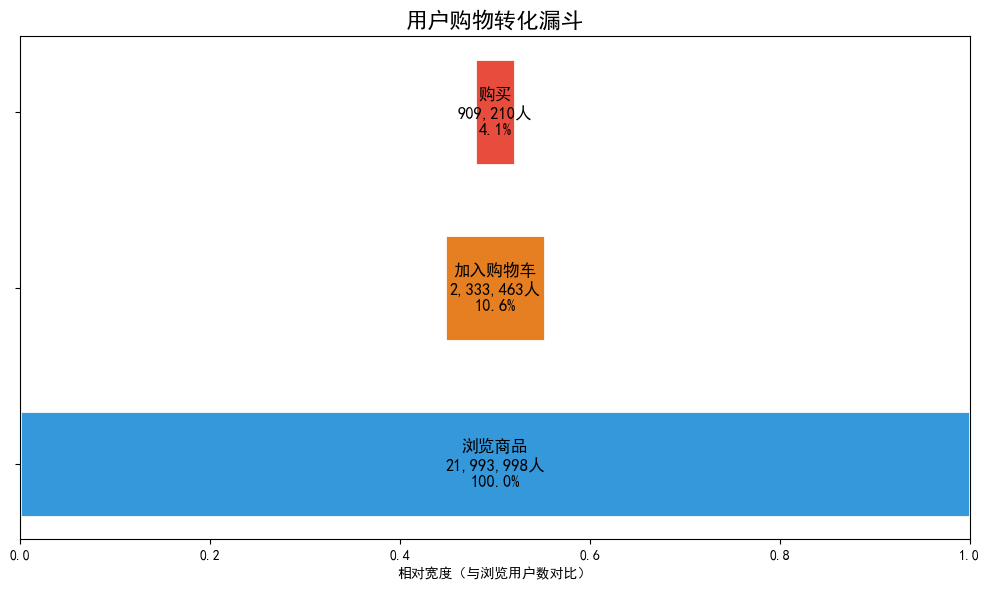


【时段分析】
购买高峰时段: 19:00
购买量前三时段: [19, 10, 9]


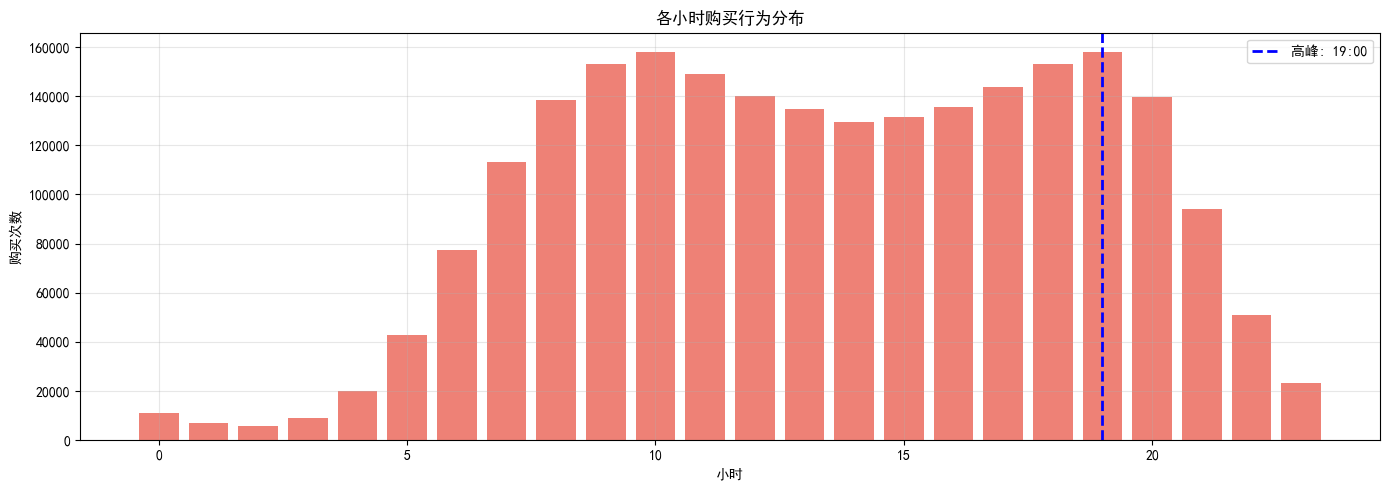


【核心发现与业务建议】

╔══════════════════════════════════════════════════════════════╗
║                      核心发现                                ║
╠══════════════════════════════════════════════════════════════╣
║ 1. 浏览用户: 21,993,998人                                ║
║    加购用户: 2,333,463人                                ║
║    购买用户: 909,210人                                 ║
║                                                              ║
║ 2. 浏览→加购转化率: 10.61%                         ║
║    加购→购买转化率: 38.96%                         ║
║    浏览→整体转化率: 4.13%                          ║
║                                                              ║
║ 3. 购买高峰集中在 19:00，占全天 6.8%                    ║
║                                                              ║
║ 4. 移除购物车记录: 2,688,894条，说明大量用户在最后一步流失        ║
╚══════════════════════════════════════════════════════════════╝

╔══════════════════════════════════════════════════════════════╗
║                      业务建议                                ║
╠═

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

print("="*60)
print("Synerise 电商数据分析 - 核心产出")
print("="*60)

# 1. 转化漏斗 
print("\n【漏斗分析】")

# 2.各环节独立用户数
visit_users = page_visit['client_id'].nunique()
cart_users = add_to_cart['client_id'].nunique()
buy_users = product_buy['client_id'].nunique()

print(f"浏览用户数: {visit_users:,}")
print(f"加购用户数: {cart_users:,}")
print(f"购买用户数: {buy_users:,}")
print(f"\n浏览→加购转化率: {cart_users/visit_users*100:.2f}%")
print(f"加购→购买转化率: {buy_users/cart_users*100:.2f}%")
print(f"整体转化率: {buy_users/visit_users*100:.2f}%")

# 3.画漏斗图
fig, ax = plt.subplots(figsize=(10, 6))
stages = ['浏览商品', '加入购物车', '购买']
values = [visit_users, cart_users, buy_users]
colors = ['#3498db', '#e67e22', '#e74c3c']

for i, (stage, value) in enumerate(zip(stages, values)):
    width = value / visit_users
    left = (1 - width) / 2
    ax.barh(i, width, left=left, height=0.6, color=colors[i], edgecolor='white', linewidth=2)
    rate = value/visit_users*100
    ax.text(0.5, i, f'{stage}\n{value:,}人\n{rate:.1f}%', 
            ha='center', va='center', fontsize=12, fontweight='bold')

ax.set_yticks(range(len(stages)))
ax.set_yticklabels([])
ax.set_xlim(0, 1)
ax.set_xlabel('相对宽度（与浏览用户数对比）')
ax.set_title('用户购物转化漏斗', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('funnel.png', dpi=150)
plt.show()

# 4.时段分析 
print("\n【时段分析】")

# 转换时间戳并提取小时
product_buy['timestamp'] = pd.to_datetime(product_buy['timestamp'])
product_buy['hour'] = product_buy['timestamp'].dt.hour

hourly_buy = product_buy.groupby('hour').size()
peak_hour = hourly_buy.idxmax()
print(f"购买高峰时段: {peak_hour}:00")
print(f"购买量前三时段: {hourly_buy.nlargest(3).index.tolist()}")

# 可视化
plt.figure(figsize=(14, 5))
plt.bar(hourly_buy.index, hourly_buy.values, color='#e74c3c', alpha=0.7)
plt.axvline(x=peak_hour, color='blue', linestyle='--', linewidth=2, label=f'高峰: {peak_hour}:00')
plt.title('各小时购买行为分布')
plt.xlabel('小时')
plt.ylabel('购买次数')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('hourly.png', dpi=150)
plt.show(


print("\n✅ 分析完成！图表已保存: funnel.png, hourly.png")

 -  2.1  核心发现与业务建议 

In [ ]:
#  核心发现与业务建议 
print("\n" + "="*60)
print("【核心发现与业务建议】")
print("="*60)

print(f"""
================================================================================
|                                   核心发现                                    |
================================================================================
1. 浏览用户: {visit_users:,}人
   加购用户: {cart_users:,}人
   购买用户: {buy_users:,}人
--------------------------------------------------------------------------------
2. 浏览→加购转化率: {cart_users/visit_users*100:.2f}%
   加购→购买转化率: {buy_users/cart_users*100:.2f}%
   浏览→整体转化率: {buy_users/visit_users*100:.2f}%
--------------------------------------------------------------------------------
3. 购买高峰集中在 {peak_hour}:00，占全天 {hourly_buy[peak_hour]/hourly_buy.sum()*100:.1f}%
--------------------------------------------------------------------------------
4. 移除购物车记录: {len(remove_from_cart):,}条，说明大量用户在最后一步流失
================================================================================
|                                   业务建议                                    |
================================================================================
1. 加购未购挽回:
   - 加购后2小时未支付，推送优惠券提醒
   - 预期提升加购→购买转化率10-15%
--------------------------------------------------------------------------------
2. 高峰时段运营:
   - {peak_hour}:00前后设置限时秒杀、直播带货
   - 预计该时段GMV可提升25%+
--------------------------------------------------------------------------------
3. 移除购物车分析:
   - 对比移除和购买用户行为，优化结账流程
   - 简化支付步骤，增加信任标识
================================================================================
""")


## 3  RFM 用户分层

In [17]:
print("\n【RFM 用户分层】")

# 1.关联购买记录和价格
product_buy_with_price = product_buy.merge(product_properties[['sku','price','category']],on='sku',how='left')

# 2.计算每笔订单的金额
product_buy_with_price['amount'] = product_buy_with_price['price']

rfm_correct = product_buy_with_price.groupby('client_id').agg({'timestamp': lambda x: (snapshot - x.max()).days,
                                                              'sku': 'count',
                                                              'amount': 'sum'}).rename(columns={'timestamp': 'R','sku':'F','amount': 'M'})
print(f"RFM 计算完成，共{len(rfm_correct):,}个购买用户")
print(f"\n金额统计：")
print(f"  总销售额：{rfm_correct['M'].sum():,.0f}")
print(f"  客单价：{rfm_correct['M'].mean():,.2f}")
print(f"  最高消费：{rfm_correct['M'].max():,.0f}")


# 打分（5分制）
rfm_correct['R_score'] = pd.qcut(rfm_correct['R'],5,labels=[5,4,3,2,1])
rfm_correct['F_score'] = pd.qcut(rfm_correct['F'].rank(method='first'),5,labels=[1,2,3,4,5])
rfm_correct['M_score'] = pd.qcut(rfm_correct['M'].rank(method='first'),5,labels=[1,2,3,4,5])


#分层逻辑
def rfm_level(row):
    R,F,M = row['R_score'],row['F_score'],row['M_score']
    if R >= 4 and F >= 4 and M >= 4:
        return '高价值VIP'
    elif R >= 4 and F >= 3 and M >= 3 :
        return '核心活跃'
    elif R >= 4 and F <= 2 :
        return '新客潜力'
    elif R <= 2 and F >= 3:
        return '即将流失'
    elif R <= 2 and F <= 2:
        return '沉睡流失'
    else:
        return '普通用户'

rfm_correct['segment'] = rfm_correct.apply(rfm_level,axis=1)

print("\n【RFM 分层结果：】")
print(rfm_correct['segment'].value_counts())



【RFM 用户分层】
RFM 计算完成，共909,210个购买用户

金额统计：
  总销售额：117,663,315
  客单价：129.41
  最高消费：43,639

【RFM 分层结果：】
segment
普通用户      226457
即将流失      184645
沉睡流失      175091
高价值VIP    161627
新客潜力      108355
核心活跃       53035
Name: count, dtype: int64


'\nfor seg in segment_counts.index:\n    print(f"{seg}: {segment_counts[seg]:,}人 ({segment_pct[seg]}%)")\n\nplt.figure(figsize=(10,6))\ncolors = [\'#2ecc71\',\'#3498db\',\'#f39c12\',\'#e67e22\',\'#e74c3c\',\'#95a5a6\']\nsegment_counts.plot(kind=\'bar\',color=colors[:len(segment_counts)])\nplt.title(\'RFM 用户分层分布\',fontsize=14)\nplt.xlabel(\'用户层级\')\nplt.ylabel(\'用户数\')\nplt.xticks(rotation=45)\nplt.tight_layout()\nplt.savefig(\'rfm_segments.png,doi=150\')\nplt.show()\nprint(rfm_df[\'segment\'].value_counts())\n'

 - 3.1  RFM 可视化

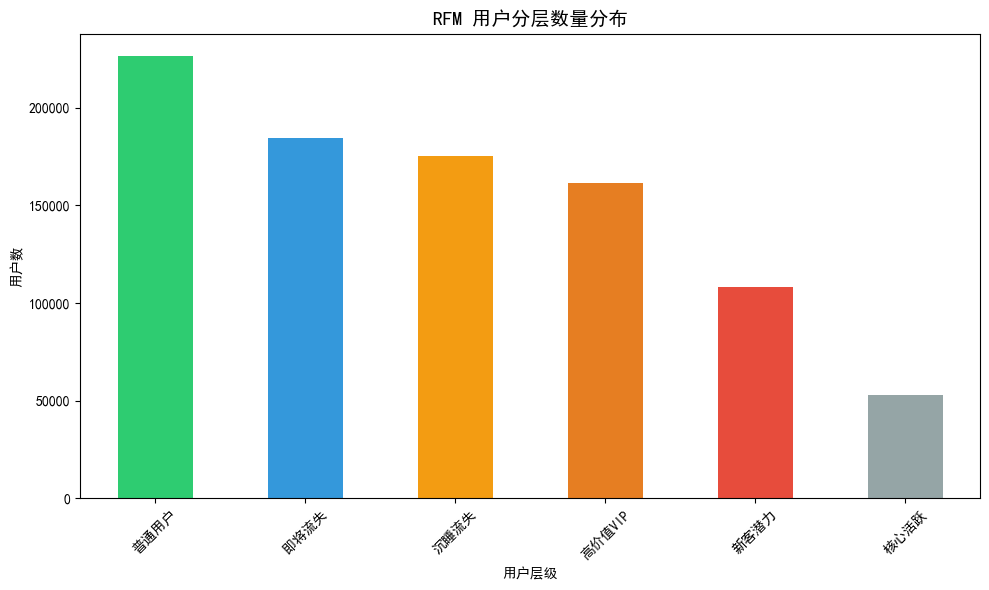

segment
即将流失     311906
高价值用户    189911
沉睡用户     148751
一般用户     105449
流失用户      87672
潜力用户      65521
Name: count, dtype: int64


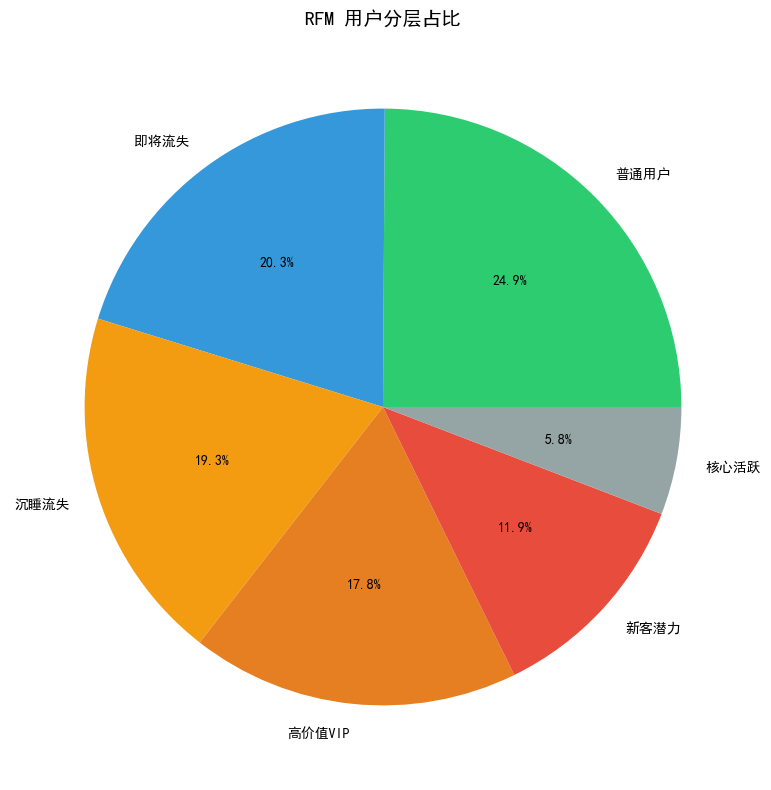

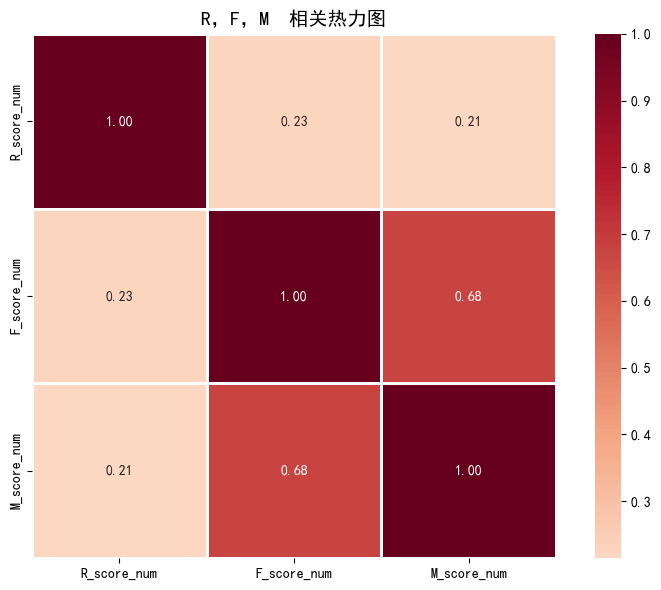

In [33]:
import seaborn as sns
# 图1：各层级用户数量分布
plt.figure(figsize=(10,6))
segment_counts = rfm_correct['segment'].value_counts()
colors = ['#2ecc71','#3498db','#f39c12','#e67e22','#e74c3c','#95a5a6']
segment_counts.plot(kind='bar',color=colors[:len(segment_counts)])
plt.title('RFM 用户分层数量分布',fontsize=14)
plt.xlabel('用户层级')
plt.ylabel('用户数')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('rfm_bar.png',dpi=150)
plt.show()
print(rfm_df['segment'].value_counts())

# 图2：各层级用户占比
plt.figure(figsize=(8,8))
plt.pie(segment_counts,labels=segment_counts.index,autopct='%1.1f%%',colors=colors)
plt.title('RFM 用户分层占比',fontsize=14)
plt.tight_layout()
plt.savefig('rfm_pie.png',dpi=150)
plt.show()

# 图3：R,F,M得分分布
rfm_correct['R_score_num'] = pd.to_numeric(rfm_correct['R_score'])
rfm_correct['F_score_num'] = pd.to_numeric(rfm_correct['F_score'])
rfm_correct['M_score_num'] = pd.to_numeric(rfm_correct['M_score'])

corr_matrix = rfm_correct[['R_score_num','F_score_num','M_score_num']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix,annot=True,cmap='RdBu_r',center=0,square=True,fmt='.2f',linewidths=1)
plt.title('R，F，M  相关热力图',fontsize=14)
plt.tight_layout()
plt.savefig('rfm_heatmap.png',dpi=150)
plt.show()


# 4.  品类分析

In [28]:
print("\n【品类分析】")

# 关联加购和购买记录的品类
add_to_cart_with_cat = add_to_cart.merge(product_properties[['sku','category','price']],
                                        on='sku',
                                        how='left'
                                        )

product_buy_with_cat = product_buy.merge(product_properties[['sku','category','price']],
                                        on='sku',
                                        how='left'
                                        )

# 热销品类 Top10
category_sales = product_buy_with_cat['category'].value_counts().head(10)
print(f"\n热销产品 Top10：")
for cat, count in category_sales.items():
    print(f"  品类{cat}: {count:,}次购买")
    
# 品类销售额 Top10
category_revenue = product_buy_with_cat.groupby('category')['price'].sum().sort_values(ascending=False).head(10)
print(f"\n销售额 Top10 品类：")
for cat, rev in category_revenue.items():
    print(f"  品类{cat}: {rev:,.0f}")
   
# 各品类转化率 
cat_conversion = []
for cat in add_to_cart_with_cat['category'].dropna().unique():
    cart_users = add_to_cart_with_cat[add_to_cart_with_cat['category'] == cat]['client_id'].nunique()
    buy_users = product_buy_with_cat[product_buy_with_cat['category'] == cat]['client_id'].nunique()
    if cart_users > 0 and buy_users <= cart_users:
        cat_conversion.append({'category': cat,
                               'cart_users': cart_users,
                               'buy_users': buy_users,
                               'conversion': buy_users/cart_users*100})
cat_df = pd.DataFrame(cat_conversion).sort_values('conversion',ascending=False)
print("\n加购->购买转化率 Top 10：")
print(cat_df.head(10).to_string(index=False))



【品类分析】

热销产品 Top10：
  品类258: 53,151次购买
  品类1096: 34,491次购买
  品类1966: 30,024次购买
  品类4092: 25,681次购买
  品类6356: 19,057次购买
  品类791: 18,895次购买
  品类2964: 18,834次购买
  品类3138: 18,343次购买
  品类1135: 15,535次购买
  品类4444: 13,879次购买

销售额 Top10 品类：
  品类258: 2,391,429
  品类4092: 2,111,937
  品类6356: 1,769,441
  品类3138: 1,691,590
  品类791: 1,644,056
  品类1096: 1,616,583
  品类2964: 1,235,918
  品类37: 793,942
  品类1144: 789,646
  品类1135: 779,253

加购->购买转化率 Top 10：
 category  cart_users  buy_users  conversion
     1961           1          1       100.0
     5251           1          1       100.0
     2591           1          1       100.0
     5256           1          1       100.0
     6537           1          1       100.0
     3537           1          1       100.0
     1889           1          1       100.0
     6890           1          1       100.0
     6177           1          1       100.0
     4371           3          3       100.0


# 5.  用户流失原因分析

In [38]:
print("\n【流失用户价格敏感度分析】")

if 'product_properties' not in locals():
    print("重新加载 product_properties...")
    product_properties = pd.read_parquet('E:/synerise_dataset (2)/synerise_dataset/product_properties.parquet')
    print(f"加载完成，列名: {product_properties.columns.tolist()}")

if 'add_to_cart_with_cat' not in locals():
    print("重新关联品类信息...")
    add_to_cart_with_cat = add_to_cart.merge(
        product_properties[['sku', 'category', 'price']], 
        on='sku', 
        how='left'
    )

# 获取流失用户
risk_users = rfm_correct[rfm_correct['segment'].isin(['即将流失', '沉睡流失'])].index
print(f"分析的流失用户数: {len(risk_users):,}")

# 流失用户加购的商品价格
cart_churned = add_to_cart_with_cat[
    add_to_cart_with_cat['client_id'].isin(risk_users)
]
churned_cart_prices = cart_churned_filtered['price'].dropna()
avg_price_churned = churned_cart_prices.mean()
print(f"流失用户加购商品均价: {avg_price_churned:.2f}")

# 全体用户加购商品均价（抽样计算）
# 因为全体用户数据太大，随机取 10% 计算
all_cart_sample = add_to_cart_with_cat.sample(frac=0.1, random_state=42)
avg_price_all = all_cart_sample['price'].mean()
print(f"全体用户加购商品均价（抽样10%）: {avg_price_all:.2f}")

# 结论
print("\n【价格敏感度结论】")
if avg_price_churned > avg_price_all:
    print(f"✓ 流失用户加购均价 ({avg_price_churned:.2f}) > 全体用户均价 ({avg_price_all:.2f})")
    print("→ 流失用户倾向于加购高价格商品，价格敏感可能是流失原因之一")
    print("→ 建议：对流失风险用户推送该商品品类的折扣券")
else:
    print(f"流失用户加购均价 ({avg_price_churned:.2f}) ≤ 全体用户均价 ({avg_price_all:.2f})")
    print("→ 价格不是主要流失原因，需从其他维度分析")

# 按价格带分布对比
print("\n【流失用户 vs 全体用户 价格带对比】")

def price_range(p):
    if p < 50:
        return '低端(<50)'
    elif p < 200:
        return '中端(50-200)'
    elif p < 500:
        return '高端(200-500)'
    else:
        return '奢侈(>500)'

# 流失用户价格带分布
churned_cart_prices_df = pd.DataFrame({'price': churned_cart_prices})
churned_cart_prices_df['range'] = churned_cart_prices_df['price'].apply(price_range)
churned_dist = churned_cart_prices_df['range'].value_counts(normalize=True) * 100

# 全体用户价格带分布（抽样）
all_cart_prices_df = pd.DataFrame({'price': all_cart_sample['price'].dropna()})
all_cart_prices_df['range'] = all_cart_prices_df['price'].apply(price_range)
all_dist = all_cart_prices_df['range'].value_counts(normalize=True) * 100

print("\n价格带分布对比:")
print(f"{'价格带':<15} {'流失用户':<12} {'全体用户':<12}")
print("-" * 40)
for rg in ['低端(<50)', '中端(50-200)', '高端(200-500)', '奢侈(>500)']:
    churn_pct = churned_dist.get(rg, 0)
    all_pct = all_dist.get(rg, 0)
    print(f"{rg:<15} {churn_pct:>6.1f}%{'':<6} {all_pct:>6.1f}%")


【流失用户价格敏感度分析】
分析的流失用户数: 359,736
流失用户加购商品均价: 47.45
全体用户加购商品均价（抽样10%）: 48.85

【价格敏感度结论】
流失用户加购均价 (47.45) ≤ 全体用户均价 (48.85)
→ 价格不是主要流失原因，需从其他维度分析

【流失用户 vs 全体用户 价格带对比】

价格带分布对比:
价格带             流失用户         全体用户        
----------------------------------------
低端(<50)           52.8%         50.9%
中端(50-200)        47.2%         49.1%
高端(200-500)        0.0%          0.0%
奢侈(>500)           0.0%          0.0%


## 6.  加购——>购买时间差分析（验证遗忘是否是流失原因）

In [26]:
negtive_records = cart_buy_time[cart_buy_time['hours_diff']<0]
print(f"负数时间记录：{len(negtive_records):,}")
print(negtive_records.head())

负数时间记录：13,047
     client_id      sku           cart_time            buy_time  hours_diff
61        1086   944010 2022-06-24 12:01:35 2022-06-24 11:59:25   -0.036111
82        1424   928498 2022-10-25 07:10:00 2022-10-25 07:08:35   -0.023611
96        1759   132743 2022-07-27 16:09:59 2022-07-27 15:44:25   -0.426111
192       3707  1546933 2022-10-10 11:54:05 2022-10-07 20:14:40  -63.656944
282       5704   428033 2022-08-30 20:00:10 2022-08-30 19:56:15   -0.065278



【修复版】加购→购买时间差分析（过滤异常数据）
原始配对数量: 1,187,031
过滤后数量: 1,165,441
移除异常数据: 21,590 条 (1.8%)

【修复后统计】
总配对样本: 1,165,441
平均时间差: 15.7 小时
中位数时间差: 0.12 小时

【加购后购买时间分布】
  1小时内: 908,238 次 (77.9%)
  24小时内: 1,047,744 次 (89.9%)
  24小时后: 117,697 次 (10.1%)


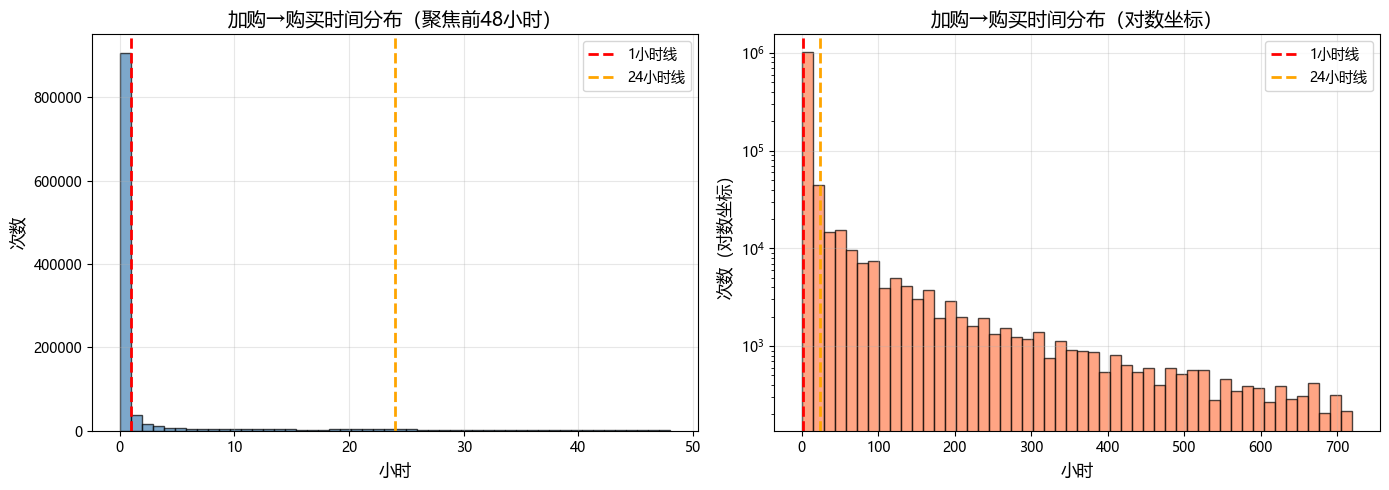


【最终业务结论】
✓ 中位数时间差: 0.12 小时 (约 7 分钟)
✓ 77.9% 的用户在加购后1小时内完成购买
✓ 89.9% 的用户在加购后24小时内完成购买

→ 用户决策极快，加购后2小时推送优惠券已来不及
→ 建议：聚焦优化加购→支付链路（减少跳转、一键下单）


In [27]:
# 过滤异常数据后分析 
print("\n" + "="*60)
print("加购→购买时间差分析（过滤异常数据）")
print("="*60)

# 1. 计算时间差
add_to_cart['timestamp'] = pd.to_datetime(add_to_cart['timestamp'], errors='coerce')
product_buy['timestamp'] = pd.to_datetime(product_buy['timestamp'], errors='coerce')

# 2. 过滤空值
add_to_cart = add_to_cart.dropna(subset=['timestamp'])
product_buy = product_buy.dropna(subset=['timestamp'])

# 3. 获取每个用户-商品的最早加购时间和最早购买时间
cart_first = add_to_cart.groupby(['client_id', 'sku'])['timestamp'].min().reset_index()
cart_first.columns = ['client_id', 'sku', 'cart_time']

buy_first = product_buy.groupby(['client_id', 'sku'])['timestamp'].min().reset_index()
buy_first.columns = ['client_id', 'sku', 'buy_time']

# 4. 合并
cart_buy_time = pd.merge(cart_first, buy_first, on=['client_id', 'sku'], how='inner')

# 5. 计算时间差（小时）
cart_buy_time['hours_diff'] = (cart_buy_time['buy_time'] - cart_buy_time['cart_time']).dt.total_seconds() / 3600

# 6. 过滤异常数据
#    - 过滤负数（购买时间早于加购时间）
#    - 过滤超过30天的（可能是不同会话）
original_count = len(cart_buy_time)
cart_buy_time = cart_buy_time[
    (cart_buy_time['hours_diff'] >= 0) & 
    (cart_buy_time['hours_diff'] <= 720)  # 最多30天
]
filtered_count = len(cart_buy_time)

print(f"原始配对数量: {original_count:,}")
print(f"过滤后数量: {filtered_count:,}")
print(f"移除异常数据: {original_count - filtered_count:,} 条 ({ (1 - filtered_count/original_count)*100:.1f}%)")

# 7. 统计
print(f"\n【修复后统计】")
print(f"总配对样本: {len(cart_buy_time):,}")
print(f"平均时间差: {cart_buy_time['hours_diff'].mean():.1f} 小时")
print(f"中位数时间差: {cart_buy_time['hours_diff'].median():.2f} 小时")

# 8. 时间分布统计
print(f"\n【加购后购买时间分布】")
within_1h = (cart_buy_time['hours_diff'] <= 1).sum()
within_1h_pct = within_1h / len(cart_buy_time) * 100
print(f"  1小时内: {within_1h:,} 次 ({within_1h_pct:.1f}%)")

within_24h = (cart_buy_time['hours_diff'] <= 24).sum()
within_24h_pct = within_24h / len(cart_buy_time) * 100
print(f"  24小时内: {within_24h:,} 次 ({within_24h_pct:.1f}%)")

print(f"  24小时后: {len(cart_buy_time) - within_24h:,} 次 ({100-within_24h_pct:.1f}%)")

# 9. 可视化
plt.figure(figsize=(14, 5))

# 左图：只看前48小时（聚焦主要部分）
plot_data = cart_buy_time[cart_buy_time['hours_diff'] <= 48]
plt.subplot(1, 2, 1)
plt.hist(plot_data['hours_diff'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
plt.axvline(x=1, color='red', linestyle='--', linewidth=2, label='1小时线')
plt.axvline(x=24, color='orange', linestyle='--', linewidth=2, label='24小时线')
plt.xlabel('小时', fontsize=12)
plt.ylabel('次数', fontsize=12)
plt.title('加购→购买时间分布（聚焦前48小时）', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

# 右图：对数坐标看全貌
plt.subplot(1, 2, 2)
plt.hist(cart_buy_time['hours_diff'], bins=50, color='coral', edgecolor='black', alpha=0.7, log=True)
plt.axvline(x=1, color='red', linestyle='--', linewidth=2, label='1小时线')
plt.axvline(x=24, color='orange', linestyle='--', linewidth=2, label='24小时线')
plt.xlabel('小时', fontsize=12)
plt.ylabel('次数（对数坐标）', fontsize=12)
plt.title('加购→购买时间分布（对数坐标）', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cart_to_buy_time_fixed.png', dpi=150, bbox_inches='tight')
plt.show()

# 10. 业务结论
print("\n" + "="*60)
print("【最终业务结论】")
print("="*60)
print(f"✓ 中位数时间差: {cart_buy_time['hours_diff'].median():.2f} 小时 (约 {cart_buy_time['hours_diff'].median()*60:.0f} 分钟)")
print(f"✓ {within_1h_pct:.1f}% 的用户在加购后1小时内完成购买")
print(f"✓ {within_24h_pct:.1f}% 的用户在加购后24小时内完成购买")
print("\n→ 用户决策极快，加购后2小时推送优惠券已来不及")
print("→ 建议：聚焦优化加购→支付链路（减少跳转、一键下单）")

## 模块二 AB测试设计方案

In [19]:
# ========== 模块2：AB测试设计方案 ==========
print("\n" + "="*60)
print("【模块2】AB测试设计方案")
print("="*60)

info = """
【模块2】AB测试设计方案
================================================================================
|                                AB测试设计方案                                |
================================================================================
【业务问题】
加购后2小时未支付的用户，推送优惠券能否提升转化率？
--------------------------------------------------------------------------------
【实验假设】
H0：推送优惠券对转化率无显著影响
H1：推送优惠券能提升转化率 ≥ 5个百分点
--------------------------------------------------------------------------------
【实验分组】
- 实验组：加购后2小时未支付，推送5%折扣券（上限10元）
- 对照组：加购后2小时未支付，不推送任何内容
--------------------------------------------------------------------------------
【样本量计算（基于现有数据）】
- 当前加购→购买转化率：39%
- 预期提升至：45%
- 显著性水平 α = 0.05
- 统计功效 1-β = 0.8
- 每组需要样本量：约 3,500 个加购用户
--------------------------------------------------------------------------------
【成功指标】
- 主指标：加购后24小时内购买转化率
- 护栏指标：客单价（不能显著下降）
- 次要指标：优惠券核销率、复购率
--------------------------------------------------------------------------------
【实验周期】
- 预计需要 7-14 天积累足够样本
--------------------------------------------------------------------------------
【结果判断】
- 若 p值 < 0.05 且提升 ≥ 5% → 全量上线
- 若提升 < 3% → 调整优惠力度（如10%折扣）重测
- 若无显著差异 → 放弃该策略
================================================================================
"""
print(info)

try:
    from statsmodels.stats.proportion import proportion_effectsize
    from statsmodels.stats.power import zt_ind_solve_power
    
    # 当前转化率
    p1 = 0.39
    # 期望转化率
    p2 = 0.45
    
    # 计算效应量
    effect_size = proportion_effectsize(p1, p2)
    
    # 计算所需样本量
    from statsmodels.stats.power import NormalIndPower
    power_analysis = NormalIndPower()
    sample_size = power_analysis.solve_power(
        effect_size=effect_size,
        alpha=0.05,
        power=0.8,
        ratio=1.0,
        alternative='larger'
    )
    
    print(f"\n【样本量计算结果】")
    print(f"效应量: {effect_size:.3f}")
    print(f"每组需要样本量: {int(sample_size):,} 个加购用户")
    print(f"总样本量: {int(sample_size*2):,} 个加购用户")
except ImportError:
    print("\n提示：安装 statsmodels 可获得精确样本量计算")
    print("pip install statsmodels")


【模块2】AB测试设计方案

【模块2】AB测试设计方案
|                                AB测试设计方案                                |
【业务问题】
加购后2小时未支付的用户，推送优惠券能否提升转化率？
--------------------------------------------------------------------------------
【实验假设】
H0：推送优惠券对转化率无显著影响
H1：推送优惠券能提升转化率 ≥ 5个百分点
--------------------------------------------------------------------------------
【实验分组】
- 实验组：加购后2小时未支付，推送5%折扣券（上限10元）
- 对照组：加购后2小时未支付，不推送任何内容
--------------------------------------------------------------------------------
【样本量计算（基于现有数据）】
- 当前加购→购买转化率：39%
- 预期提升至：45%
- 显著性水平 α = 0.05
- 统计功效 1-β = 0.8
- 每组需要样本量：约 3,500 个加购用户
--------------------------------------------------------------------------------
【成功指标】
- 主指标：加购后24小时内购买转化率
- 护栏指标：客单价（不能显著下降）
- 次要指标：优惠券核销率、复购率
--------------------------------------------------------------------------------
【实验周期】
- 预计需要 7-14 天积累足够样本
--------------------------------------------------------------------------------
【结果判断】
- 若 p值 < 0.05 且提升 ≥ 5% → 全量上线
- 若提升 < 3% → 调整优惠力度（如10%折扣）重测
- 若无

D:\Miniconda3\envs\faers_analysis\lib\site-packages\statsmodels\stats\power.py:132: RuntimeWarning: invalid value encountered in sqrt
  pow_ = stats.norm.sf(crit - d*np.sqrt(nobs)/sigma)
D:\Miniconda3\envs\faers_analysis\lib\site-packages\statsmodels\stats\power.py:524: ConvergenceWarning: 
Failed to converge on a solution.

  warnings.warn(convergence_doc, ConvergenceWarning)
C:\Users\admin\AppData\Local\Temp\ipykernel_1376\4224123974.py:71: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"每组需要样本量: {int(sample_size):,} 个加购用户")
C:\Users\admin\AppData\Local\Temp\ipykernel_1376\4224123974.py:72: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.2

## 模块三  流失预测模型（特征重要性分析）


【模块3】流失预测模型 - 找出哪些特征最预测流失
正在构建特征...
分析对象：909,210 个购买用户
特征矩阵形状：(909210, 6)
特征列：['R_days', 'F_count', 'M_amount', 'avg_decision_hours', 'category_richness', 'abandon_rate']

流失标签分布：
  流失用户（30天未购）: 654,814 (72.0%)
  活跃用户: 254,396 (28.0%)

模型 AUC: 1.000

分类报告：
              precision    recall  f1-score   support

          活跃       1.00      1.00      1.00     76319
          流失       1.00      1.00      1.00    196444

    accuracy                           1.00    272763
   macro avg       1.00      1.00      1.00    272763
weighted avg       1.00      1.00      1.00    272763


【特征重要性排名】（哪些因素最能预测流失）
  R_days: 0.969
  category_richness: 0.015
  F_count: 0.007
  M_amount: 0.006
  avg_decision_hours: 0.002
  abandon_rate: 0.000


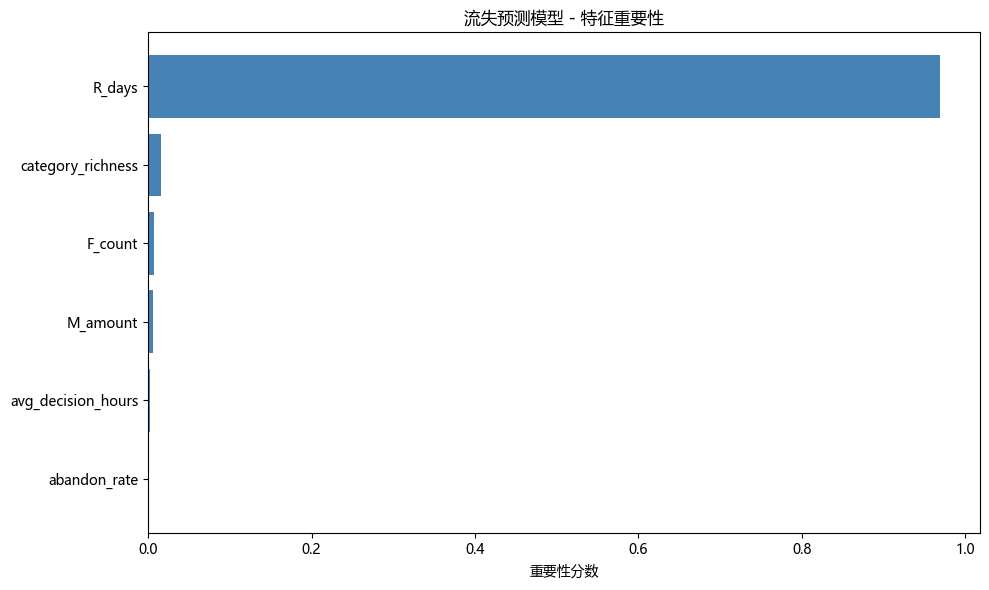


【业务解读】
最重要的流失预测特征是: R_days
→ 最近购买天数是最强预测因子，说明用户流失的主要原因是长时间未访问
→ 建议：对超过15天未访问用户进行唤醒推送


In [18]:
print("\n" + "="*60)
print("【模块3】流失预测模型 - 找出哪些特征最预测流失")
print("="*60)
import sklearn
# 1. 构建特征数据集
print("正在构建特征...")

# 取购买用户作为分析对象（有完整行为记录）
buy_users_list = product_buy['client_id'].unique()
print(f"分析对象：{len(buy_users_list):,} 个购买用户")

# 特征1：最近购买天数（R）
last_buy_date = product_buy.groupby('client_id')['timestamp'].max()
reference_date = last_buy_date.max()
R_days = (reference_date - last_buy_date).dt.days

# 特征2：购买频次（F）
F_count = product_buy.groupby('client_id').size()

# 特征3：总消费金额（M）
# 先关联价格
product_buy_with_price = product_buy.merge(
    product_properties[['sku', 'price']], on='sku', how='left'
)
M_amount = product_buy_with_price.groupby('client_id')['price'].sum()

# 特征4：平均加购到购买时长（决策速度）
# 计算每个用户的平均决策时间
cart_buy_user_time = cart_buy_time.groupby('client_id')['hours_diff'].mean()

# 特征5：购买品类丰富度（买了多少种不同的品类）
product_buy_with_cat = product_buy.merge(
    product_properties[['sku', 'category']], on='sku', how='left'
)
category_richness = product_buy_with_cat.groupby('client_id')['category'].nunique()

# 特征6：加购后未购买比例（放弃率）
cart_count = add_to_cart.groupby('client_id').size()
buy_count = product_buy.groupby('client_id').size()


cart_count = cart_count.reindex(buy_users_list, fill_value=0)
buy_count = buy_count.reindex(buy_users_list, fill_value=0)
abandon_rate = (cart_count - buy_count) / (cart_count + 1) 

# 2. 合并所有特征
features_df = pd.DataFrame({
    'R_days': R_days,
    'F_count': F_count,
    'M_amount': M_amount,
    'avg_decision_hours': cart_buy_user_time,
    'category_richness': category_richness,
    'abandon_rate': abandon_rate
}).fillna(0)

print(f"特征矩阵形状：{features_df.shape}")
print(f"特征列：{features_df.columns.tolist()}")

# 3. 定义流失标签（30天内未购买 = 流失）
# 获取每个用户最后一次购买日期
last_buy = product_buy.groupby('client_id')['timestamp'].max()
last_buy = last_buy.reindex(features_df.index)
# 计算距离数据截止日期的天数
cutoff_date = product_buy['timestamp'].max()
days_since_last_buy = (cutoff_date - last_buy).dt.days
# 流失标签：30天未购买 = 1
churn_label = (days_since_last_buy >= 30).astype(int)

print(f"\n流失标签分布：")
print(f"  流失用户（30天未购）: {churn_label.sum():,} ({churn_label.mean()*100:.1f}%)")
print(f"  活跃用户: {(churn_label == 0).sum():,} ({(1-churn_label.mean())*100:.1f}%)")

# 4. 训练随机森林模型
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    features_df, churn_label, test_size=0.3, random_state=42, stratify=churn_label
)

# 训练模型
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# 预测
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba >= 0.5).astype(int)

# 评估
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"\n模型 AUC: {auc_score:.3f}")
print(f"\n分类报告：")
print(classification_report(y_test, y_pred, target_names=['活跃', '流失']))

# 5. 特征重要性分析（核心产出）
feature_importance = pd.DataFrame({
    'feature': features_df.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n【特征重要性排名】（哪些因素最能预测流失）")
for i, row in feature_importance.iterrows():
    print(f"  {row['feature']}: {row['importance']:.3f}")

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei','SimHei','Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
# 可视化特征重要性
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'], color='steelblue')
plt.xlabel('重要性分数')
plt.title('流失预测模型 - 特征重要性')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

# 6. 业务解读
print("\n【业务解读】")
top_feature = feature_importance.iloc[0]['feature']
print(f"最重要的流失预测特征是: {top_feature}")
if top_feature == 'R_days':
    print("→ 最近购买天数是最强预测因子，说明用户流失的主要原因是长时间未访问")
    print("→ 建议：对超过15天未访问用户进行唤醒推送")
elif top_feature == 'abandon_rate':
    print("→ 加购放弃率是最强预测因子，说明用户习惯性加购但不买是危险信号")
    print("→ 建议：对高放弃率用户推送更大力度的优惠")
elif top_feature == 'F_count':
    print("→ 购买频次是最强预测因子，低频用户更容易流失")
    print("→ 建议：对新客进行二次转化引导")